In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/content/Blood_Glucose.csv')

In [4]:
display(df.head())
display(df.info())
display(df.describe())

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Diastolic Blood Pressure Level,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N)
0,9.0,M,79.0,73.0,High,118.0,98.0,98.300707,99.0,0.0,0.0,N
1,9.0,F,80.0,73.0,High,119.0,102.0,98.300707,94.0,1.0,0.0,N
2,9.0,M,70.0,76.0,High,110.0,81.0,98.300707,98.0,1.0,0.0,N
3,9.0,F,NaN,78.0,High,115.0,96.0,98.300707,NaN,NaN,NaN,N
4,66.0,M,100.0,96.0,High,144.0,92.0,97.807052,98.0,0.0,0.0,N


<class 'pandas.DataFrame'>
RangeIndex: 16969 entries, 0 to 16968
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             16969 non-null  float64
 1   Gender                          16877 non-null  str    
 2   Blood Glucose Reading           16121 non-null  float64
 3   Diastolic Blood Pressure        16950 non-null  float64
 4   Diastolic Blood Pressure Level  16950 non-null  str    
 5   Systolic Blood Pressure         16969 non-null  float64
 6   Heart Rate                      16969 non-null  float64
 7   Body Temperature                16735 non-null  float64
 8   SPO2                            16121 non-null  float64
 9   Sweating  (Y/N)                 16121 non-null  float64
 10  Shivering (Y/N)                 16121 non-null  float64
 11  Diabetic/NonDiabetic (D/N)      16969 non-null  str    
dtypes: float64(9), str(3)
memory usage: 1.7 MB


None

,Age,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N)
count,16969.000000,16121.000000,16950.000000,16969.000000,16969.000000,16735.000000,16121.000000,16121.000000,16121.000000
mean,30.982209,95.719219,77.172537,118.183029,91.505045,97.359325,97.380645,0.121493,0.145481
std,29.736598,49.947465,8.414652,8.947304,12.084934,0.814258,0.986455,0.379650,0.409722
min,-122.524773,-162.066433,33.724424,71.984987,29.065509,96.000132,92.287436,-1.838546,-1.970002
25%,9.000000,68.000000,71.000000,113.000000,84.000000,96.674465,97.000000,0.000000,0.000000
50%,14.000000,83.000000,76.000000,118.000000,89.000000,97.331641,98.000000,0.000000,0.000000
75%,55.000000,108.000000,83.000000,124.000000,95.000000,97.953929,98.000000,0.000000,0.000000
max,184.502497,353.498975,120.622562,164.389343,153.982873,98.999792,102.476288,2.081459,2.260927


In [5]:
df.isna().sum()
#df['Body Temprature'] = df['Body Temperature'].fillna(df) # for filling the null values with mean of body temprature column
#df['Gender'] = df['Gender'].dropna() # for dropping the rows with null values of gander column
df = df.dropna() #dropping null values for entire dataset (all the columns)
df.isna().sum()

Age                               0
Gender                            0
Blood Glucose Reading             0
Diastolic Blood Pressure          0
Diastolic Blood Pressure Level    0
Systolic Blood Pressure           0
Heart Rate                        0
Body Temperature                  0
SPO2                              0
Sweating  (Y/N)                   0
Shivering (Y/N)                   0
Diabetic/NonDiabetic (D/N)        0
dtype: int64

In [6]:
display(df.duplicated().sum())
df = df.drop_duplicates()
display(df.duplicated().sum())

np.int64(136)

np.int64(0)

In [7]:
df.columns

Index(['Age', 'Gender', 'Blood Glucose Reading', 'Diastolic Blood Pressure',
       'Diastolic Blood Pressure Level', 'Systolic Blood Pressure',
       'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)',
       'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)'],
      dtype='str')

In [8]:
le = LabelEncoder()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

df['Gender'] = le.fit_transform(df['Gender'] )

df_encoded = ohe.fit_transform(df[['Diastolic Blood Pressure Level']])
encoded_feature_names = ohe.get_feature_names_out(['Diastolic Blood Pressure Level'])
df_encoded = pd.DataFrame(df_encoded, columns=encoded_feature_names, index=df.index)
df = pd.concat([df.drop('Diastolic Blood Pressure Level', axis=1), df_encoded], axis=1)

In [9]:
df

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N),Diastolic Blood Pressure Level_High
0,9.0,1,79.0,73.0,118.0,98.0,98.300707,99.0,0.0,0.0,N,1.0
1,9.0,0,80.0,73.0,119.0,102.0,98.300707,94.0,1.0,0.0,N,1.0
2,9.0,1,70.0,76.0,110.0,81.0,98.300707,98.0,1.0,0.0,N,1.0
4,66.0,1,100.0,96.0,144.0,92.0,97.807052,98.0,0.0,0.0,N,1.0
8,66.0,0,100.0,79.0,144.0,87.0,98.288617,97.0,0.0,0.0,N,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16963,9.0,0,86.0,79.0,126.0,78.0,97.029604,98.0,0.0,0.0,D,1.0
16964,9.0,0,76.0,87.0,127.0,90.0,96.842657,97.0,0.0,0.0,D,1.0
16965,9.0,0,78.0,79.0,117.0,80.0,97.869454,98.0,0.0,0.0,D,1.0
16966,9.0,1,81.0,82.0,116.0,93.0,96.766282,98.0,0.0,0.0,D,1.0


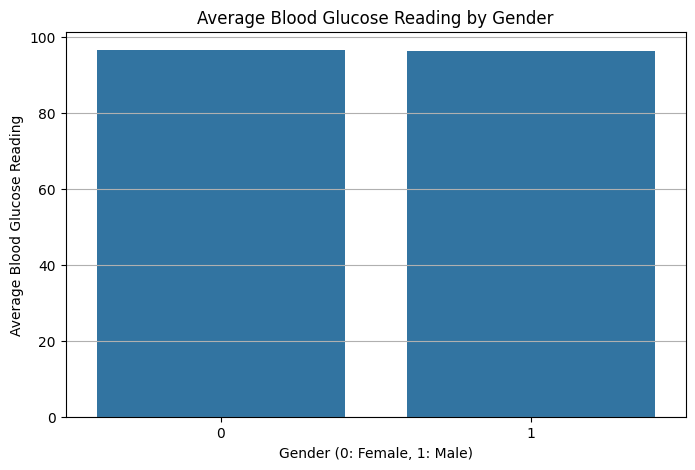

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Gender', y='Blood Glucose Reading', data=df, errorbar=None)
plt.title('Average Blood Glucose Reading by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Average Blood Glucose Reading')
plt.grid(axis='y')
plt.show()

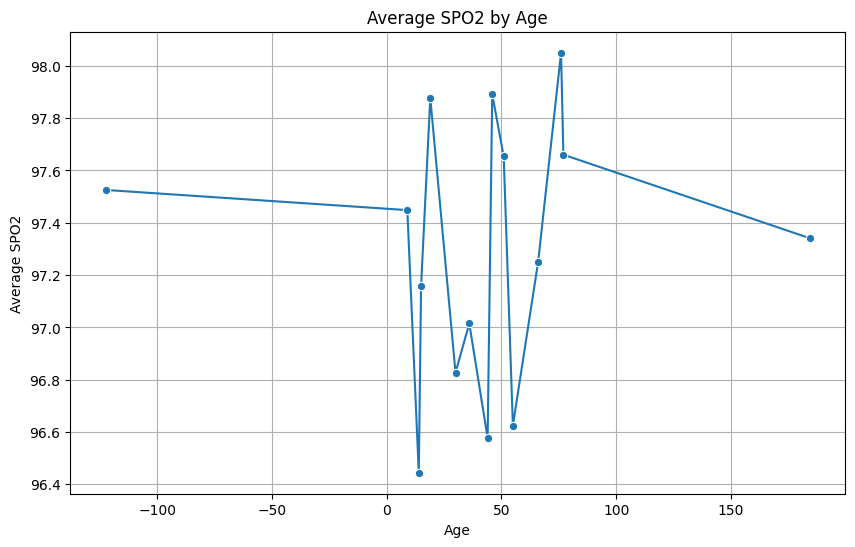

In [11]:
age_spo2_mean = df.groupby('Age')['SPO2'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age', y='SPO2', data=age_spo2_mean, marker='o')
plt.title('Average SPO2 by Age')
plt.xlabel('Age')
plt.ylabel('Average SPO2')
plt.grid(True)
plt.show()

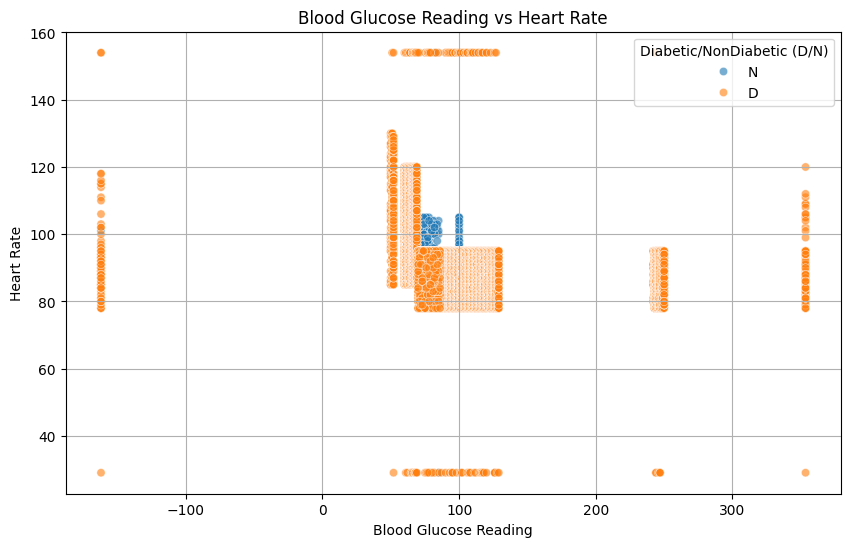

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Blood Glucose Reading', y='Heart Rate', data=df, hue='Diabetic/NonDiabetic (D/N)', alpha=0.6)
plt.title('Blood Glucose Reading vs Heart Rate')
plt.xlabel('Blood Glucose Reading')
plt.ylabel('Heart Rate')
plt.grid(True)
plt.show()

Box plots before outlier treatment:


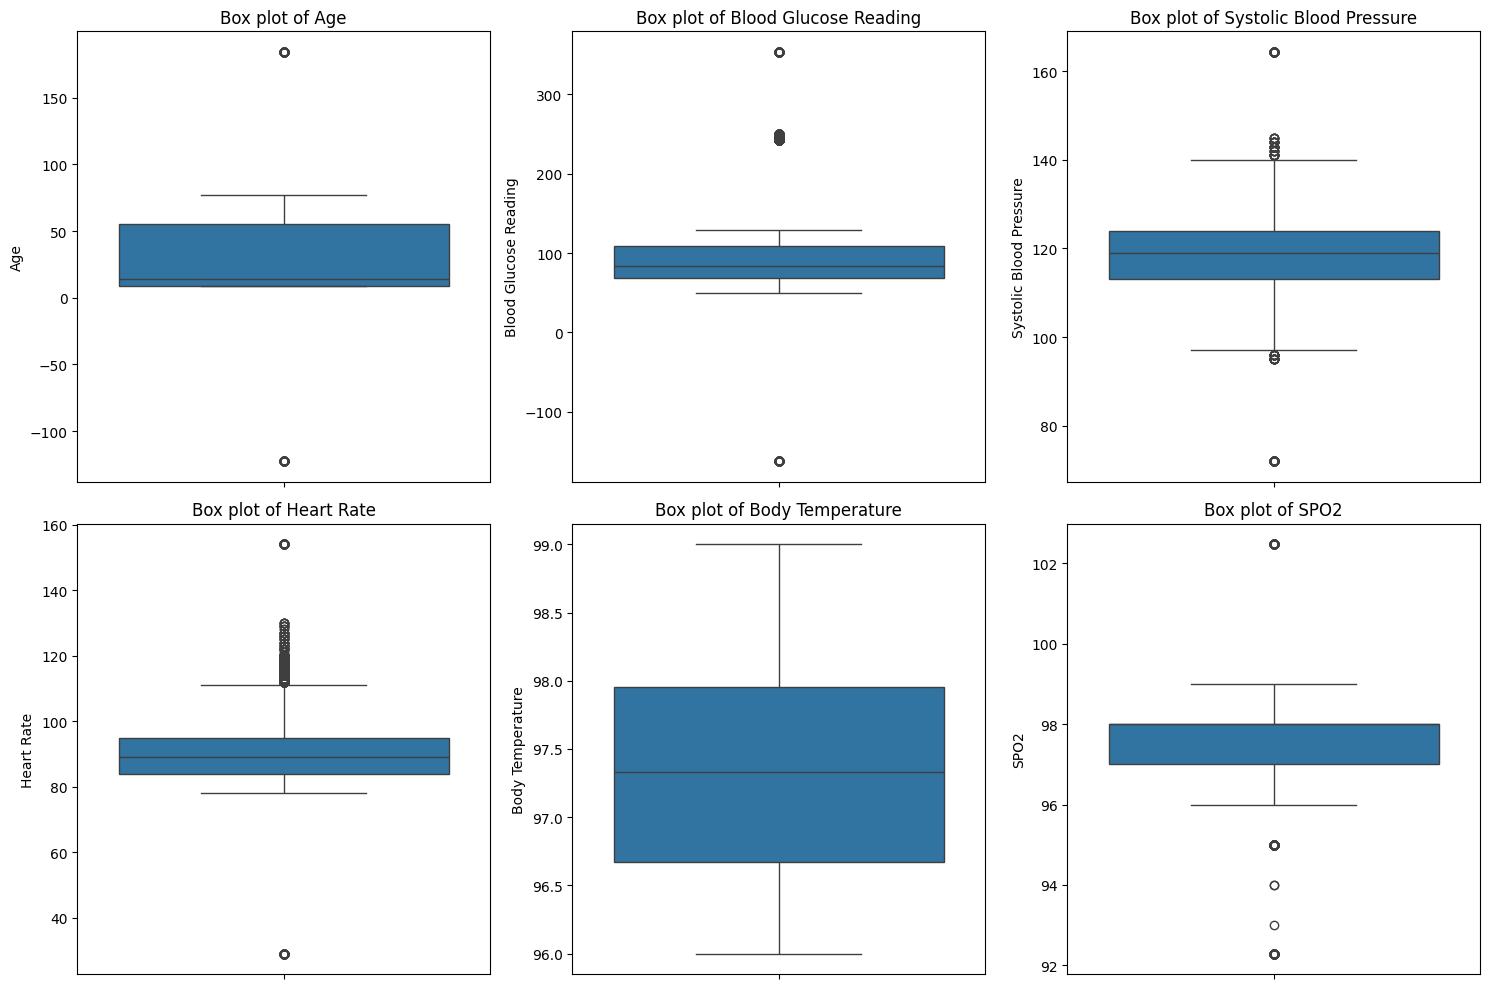

In [13]:
numerical_cols = [
    'Age',
    'Blood Glucose Reading',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2'
]

print("Box plots before outlier treatment:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
      plt.subplot(2, 3, i + 1)
      sns.boxplot(y=df[col])
      plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

In [14]:
# Capping outlier using the IQR method
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    capped_series = series.clip(lower=lower_bound, upper=upper_bound)
    return capped_series

for col in numerical_cols:
    df[col] = cap_outliers_iqr(df[col])


Box plots after outlier treatment:


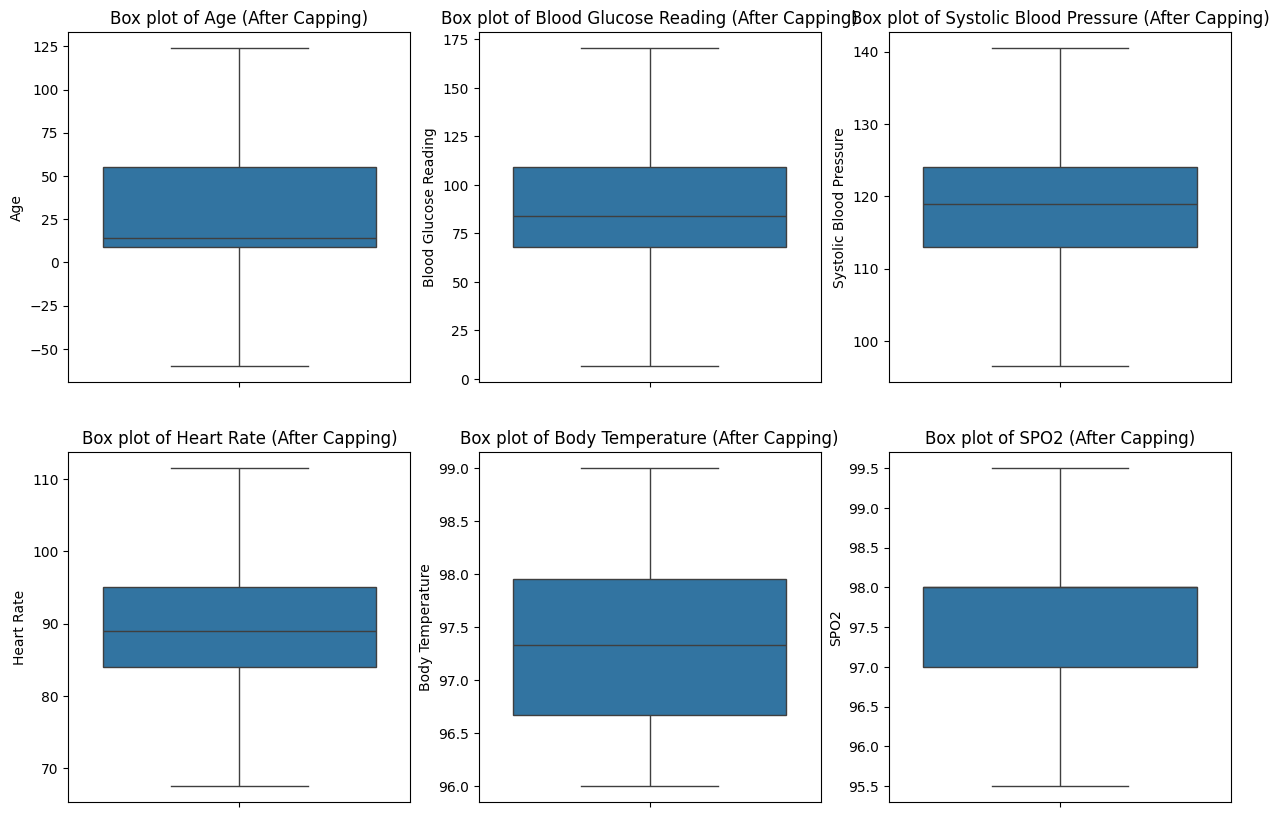

In [15]:
print("\nBox plots after outlier treatment:")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
      plt.subplot(2, 3, i + 1)
      sns.boxplot(y=df[col])
      plt.title(f'Box plot of {col} (After Capping)')
plt.show()

In [16]:
#df['Age_Group'] = pd.cut(df['Age'],bins=[0,18,35,55,75],labels=['Child', 'Young Adult', 'Adult', 'Senior'])
df['Age_Group'] = pd.cut(df['Age'],bins=[0,18,35,55,75])
df['Age_Group']
df['Interaction_Glucose_HeartRate'] = df['Blood Glucose Reading'] * df['Heart Rate']

In [17]:
df

,Age,Gender,Blood Glucose Reading,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Sweating (Y/N),Shivering (Y/N),Diabetic/NonDiabetic (D/N),Diastolic Blood Pressure Level_High,Age_Group,Interaction_Glucose_HeartRate
0,9.0,1,79.0,73.0,118.0,98.0,98.300707,99.0,0.0,0.0,N,1.0,"(0, 18]",7742.0
1,9.0,0,80.0,73.0,119.0,102.0,98.300707,95.5,1.0,0.0,N,1.0,"(0, 18]",8160.0
2,9.0,1,70.0,76.0,110.0,81.0,98.300707,98.0,1.0,0.0,N,1.0,"(0, 18]",5670.0
4,66.0,1,100.0,96.0,140.5,92.0,97.807052,98.0,0.0,0.0,N,1.0,"(55, 75]",9200.0
8,66.0,0,100.0,79.0,140.5,87.0,98.288617,97.0,0.0,0.0,N,1.0,"(55, 75]",8700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16963,9.0,0,86.0,79.0,126.0,78.0,97.029604,98.0,0.0,0.0,D,1.0,"(0, 18]",6708.0
16964,9.0,0,76.0,87.0,127.0,90.0,96.842657,97.0,0.0,0.0,D,1.0,"(0, 18]",6840.0
16965,9.0,0,78.0,79.0,117.0,80.0,97.869454,98.0,0.0,0.0,D,1.0,"(0, 18]",6240.0
16966,9.0,1,81.0,82.0,116.0,93.0,96.766282,98.0,0.0,0.0,D,1.0,"(0, 18]",7533.0


In [18]:
X = df.drop('Diabetic/NonDiabetic (D/N)',axis=1)
y = df['Diabetic/NonDiabetic (D/N)']

In [19]:
import numpy as np

ss = StandardScaler()
norm = Normalizer()

# Select only numerical columns from X
X_numeric = X.select_dtypes(include=np.number)

X_scaled = ss.fit_transform(X_numeric)
X_normalized = norm.fit_transform(X_scaled)

# Update X to be the processed numerical array
X = X_normalized

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [21]:
model_lr = LogisticRegression()
model_dt = DecisionTreeClassifier()

In [22]:
model_lr.fit(X_train,y_train)
model_dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
pred_lr = model_lr.predict(X_test)
pred_dt = model_dt.predict(X_test)

accuracy_lr = accuracy_score(y_test,pred_lr)
accuracy_dt = accuracy_score(y_test,pred_dt)

scores = {}

scores['Logistic Regression'] = accuracy_lr
scores['Decision Tree'] = accuracy_dt

print("Model Scores:")
for model_name, score in scores.items():
    print(f"{model_name}: {score:.4f}")

print("")
print("Best Model with Higher Accuracy")
best_model = max(scores, key=scores.get)
print(f"{best_model}: {scores[best_model]:.4f}")

Model Scores:
Logistic Regression: 0.9837
Decision Tree: 0.9920

Best Model with Higher Accuracy
Decision Tree: 0.9920


In [24]:
import pickle

with open('model_dt.pkl', 'wb') as f:
    pickle.dump(model_dt, f)
print("Decision Tree model saved as model_dt.pkl")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(ss, f)
print("StandardScaler saved as scaler.pkl")

with open('normalizer.pkl', 'wb') as f:
    pickle.dump(norm, f)
print("Normalizer saved as normalizer.pkl")

Decision Tree model saved as model_dt.pkl
StandardScaler saved as scaler.pkl
Normalizer saved as normalizer.pkl


## Kmeans Clustering using Elbow Method

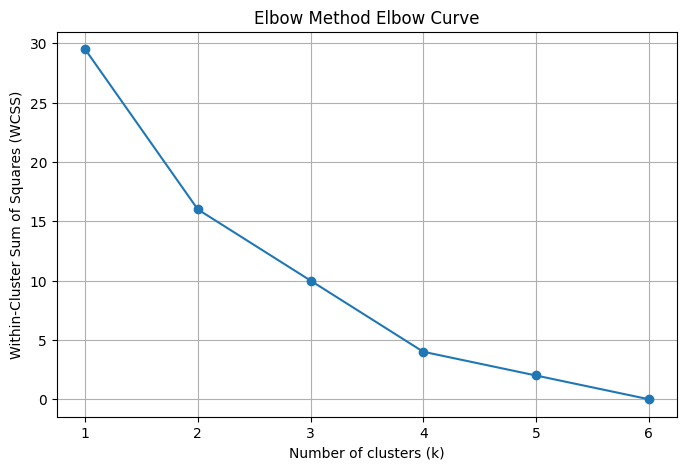

In [26]:
from sklearn.cluster import KMeans

data = np.array([[1, 2], [1, 4], [1, 0],
                 [4, 2], [4, 4], [4, 0]])

wcss = []

max_num_clusters = 6 # number of maximum cluseter is 6 as sample data points are also 6

for i in range(1, max_num_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_num_clusters + 1), wcss, marker='o')
plt.title('Elbow Method Elbow Curve')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()